In [2]:
# ============================================================
# STOCK PRICE PREDICTION USING SIMPLE LINEAR REGRESSION
# WITH FULL ASSUMPTION TESTING
# ============================================================

# ---------------------------
# 1. Import Required Libraries
# ---------------------------

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [3]:
# ---------------------------
# 2. Download Stock Data
# ---------------------------
ticker = "INDUSTOWER.NS"

In [4]:
data = yf.download(ticker, period="3mo", interval="1d")

[*********************100%***********************]  1 of 1 completed


In [5]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

In [6]:
data = data[['Close']]
data = data.dropna()

print("Downloaded Data:")
print(data.head())

Downloaded Data:
Price            Close
Date                  
2025-12-02  401.950012
2025-12-03  404.649994
2025-12-04  402.000000
2025-12-05  415.700012
2025-12-08  403.000000


In [7]:
# ---------------------------
# 3. Create Target Variable
# ---------------------------
data['Next_Close'] = data['Close'].shift(-1)
data = data.dropna()

In [8]:
#4. Define X and Y
X = data[['Close']]
Y = data['Next_Close']

In [9]:
# ---------------------------
# 5. Train-Test Split (Time Series Safe)
# ---------------------------
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

Y_train = Y.iloc[:split_index]
Y_test  = Y.iloc[split_index:]

In [10]:
# ---------------------------
# 6. Fit Simple Linear Regression
# ---------------------------
model = LinearRegression()
model.fit(X_train, Y_train)

print("\nModel Parameters:")
print("Intercept (β0):", model.intercept_)  # FIX: intercept_ is scalar for simple LR
print("Slope     (β1):", model.coef_[0])


Model Parameters:
Intercept (β0): 21.70061297217478
Slope     (β1): 0.9519817368903752


In [11]:
# ---------------------------
# 7. Predictions
# ---------------------------
Y_pred = model.predict(X_test) 

In [12]:
print(Y_pred)

[466.32367157 472.93995626 465.89529722 472.65437336 471.70239162
 476.50988777 471.89277054 473.27315568 471.22640075 469.03682533
 460.99259708 460.80218911 454.80471579]


In [13]:
# ---------------------------
# 8. Model Evaluation
# ---------------------------
print("\nModel Performance:")
print("R-squared          :", r2_score(Y_test, Y_pred))
print("Mean Squared Error :", mean_squared_error(Y_test, Y_pred))
print("RMSE               :", np.sqrt(mean_squared_error(Y_test, Y_pred)))


Model Performance:
R-squared          : 0.6155023601572653
Mean Squared Error : 26.891240862460577
RMSE               : 5.1856765096234625


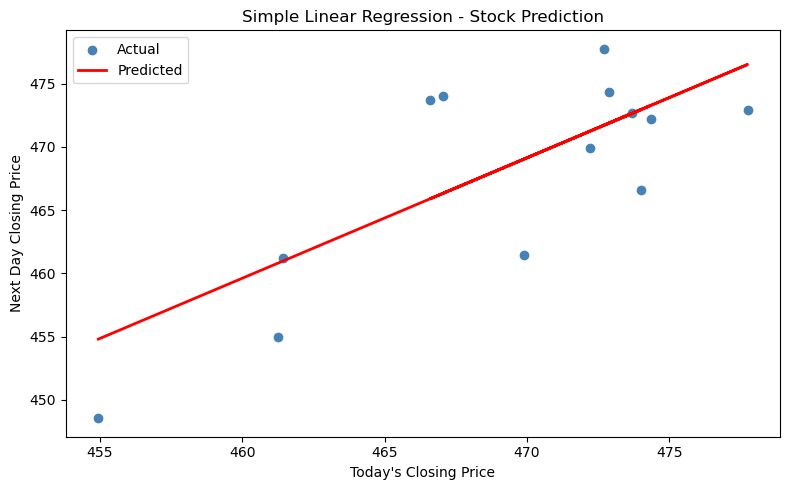

In [14]:
# ---------------------------
# 9. Visualize Regression
# ---------------------------
plt.figure(figsize=(8, 5))
plt.scatter(X_test, Y_test, color='steelblue', label='Actual')       # FIX: added color/label
plt.plot(X_test, Y_pred, color='red', linewidth=2, label='Predicted') # FIX: added color/label
plt.xlabel("Today's Closing Price")
plt.ylabel("Next Day Closing Price")
plt.title("Simple Linear Regression - Stock Prediction")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ---------------------------
# 10. Assumption Testing
# ---------------------------

# Residuals
residuals = Y_test - Y_pred
residuals = Y_test.values - Y_pred

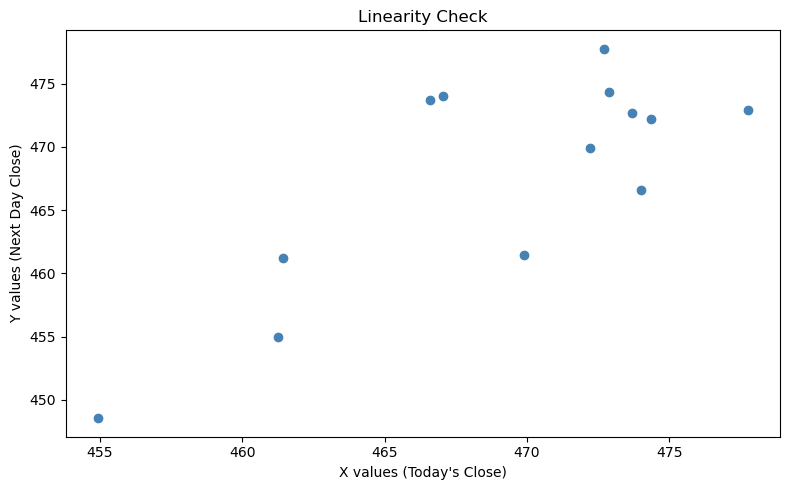

In [16]:
#10.1 Linearity (Visual Check)
plt.figure(figsize=(8, 5))
plt.scatter(X_test, Y_test, color='steelblue')
plt.xlabel("X values (Today's Close)")
plt.ylabel("Y values (Next Day Close)")
plt.title("Linearity Check")
plt.tight_layout()
plt.show()

In [17]:
# 10.2 Normality of Residuals
print("\nNormality Test (Shapiro-Wilk):")
stat, p_value = stats.shapiro(residuals)
print(f"  Statistic: {stat:.4f}, p-value: {p_value:.4f}")
print("  Interpretation:", "Normal (p > 0.05)" if p_value > 0.05 else "Not Normal (p ≤ 0.05)")


Normality Test (Shapiro-Wilk):
  Statistic: 0.9177, p-value: 0.2335
  Interpretation: Normal (p > 0.05)


<Figure size 800x500 with 0 Axes>

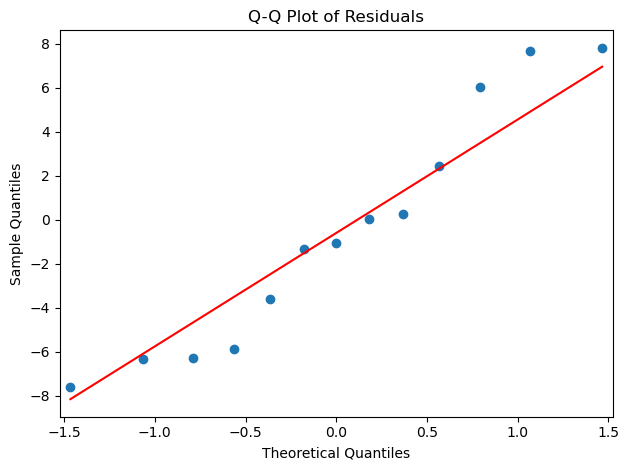

In [18]:

plt.figure(figsize=(8, 5))
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

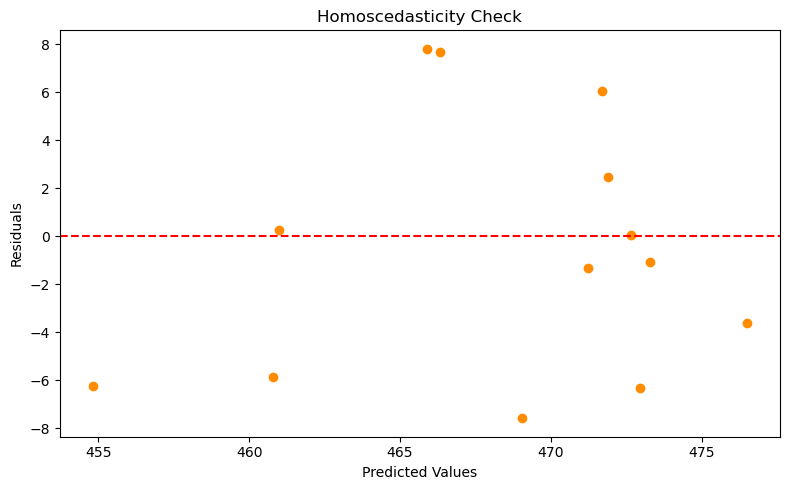

In [19]:
# 10.3 Homoscedasticity (Residual Plot)
plt.figure(figsize=(8, 5))
plt.scatter(Y_pred, residuals, color='darkorange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")
plt.tight_layout()
plt.show()

In [20]:
# 10.4 Independence of Errors (Durbin-Watson)
dw_stat = durbin_watson(residuals)
print(f"\nDurbin-Watson Statistic: {dw_stat:.4f}")
print("Interpretation:",
      "No autocorrelation (≈2)"       if 1.5 <= dw_stat <= 2.5 else
      "Positive autocorrelation (<2)" if dw_stat < 1.5 else
      "Negative autocorrelation (>2)")



Durbin-Watson Statistic: 2.2128
Interpretation: No autocorrelation (≈2)


In [21]:
# 11. Predict Next Day Price
last_closing_price = np.array([[data['Close'].iloc[-1]]])
next_day_prediction = model.predict(last_closing_price)

print("\nPredicted Next Day Closing Price: $", round(next_day_prediction[0].item(), 2))


Predicted Next Day Closing Price: $ 454.8


C:\Users\Aditi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
# 12. Residual Diagnostics:
residuals = Y_test.values - Y_pred 

In [23]:
# Normality Test
print("Shapiro-Wilk Test:", stats.shapiro(residuals))
stat, p_value = stats.shapiro(residuals)  # unpack tuple for clean output
print("\nShapiro-Wilk Test:")
print(f"  Statistic : {stat:.4f}")
print(f"  p-value   : {p_value:.4f}")
print(f"  Result    : {'Residuals are Normal (p > 0.05)' if p_value > 0.05 else 'Residuals are NOT Normal (p <= 0.05)'}")


Shapiro-Wilk Test:
  Statistic : 0.9177
  p-value   : 0.2335
  Result    : Residuals are Normal (p > 0.05)


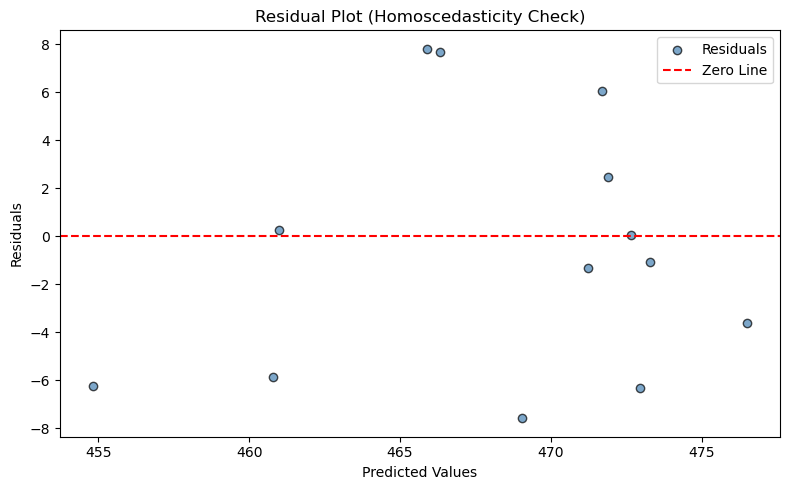

In [24]:
# Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(Y_pred, residuals, color='steelblue', edgecolors='black', alpha=0.7, label='Residuals')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero Line')  # FIX: styled line
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Homoscedasticity Check)")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

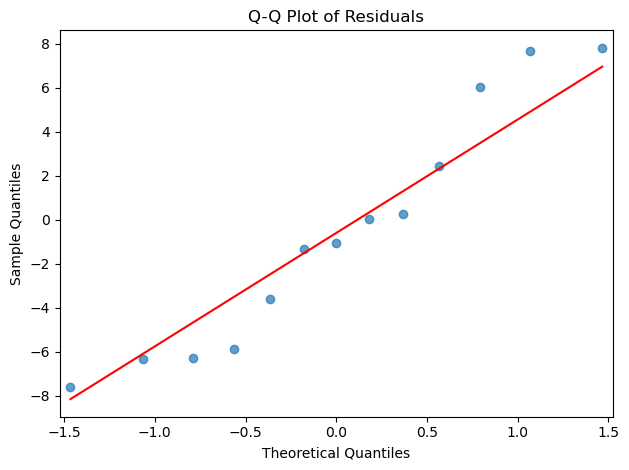

In [25]:
plt.figure(figsize=(8, 5))
sm.qqplot(residuals, line='s', alpha=0.7)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

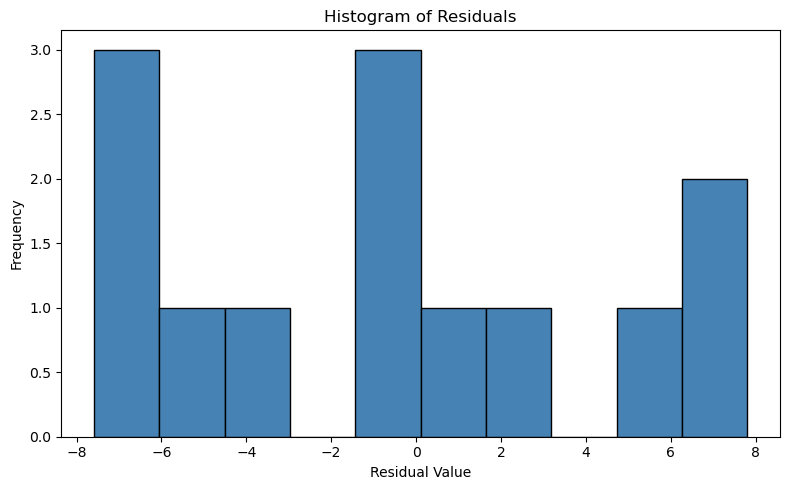

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=10, color='steelblue', edgecolor='black')
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.917696073596326), pvalue=np.float64(0.23348299603672973))


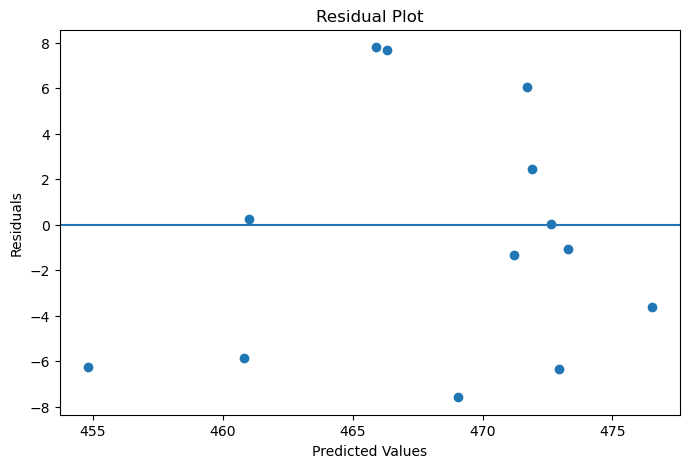

In [27]:
#11. Residual Diagnostics
residuals = Y_test - Y_pred

# Normality Test
print("Shapiro-Wilk Test:", stats.shapiro(residuals))

# Residual Plot
plt.figure(figsize=(8,5))
plt.scatter(Y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [28]:
# ---------------------------
# 11. Predict Next Day Price
# ---------------------------
last_closing_price = np.array([[data['Close'].iloc[-1]]])
next_day_prediction = model.predict(last_closing_price)

print("\nPredicted Next Day Closing Price:", next_day_prediction[0])

# ============================================================
# END OF PROJECT
# ============================================================


Predicted Next Day Closing Price: 454.8047157913218


C:\Users\Aditi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
